In [203]:
import numpy as np

In [204]:
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])
w = np.array([6, 7, 8])

In [205]:
np.outer(u, v)

array([[ 4,  5,  6],
       [ 8, 10, 12],
       [12, 15, 18]])

In [206]:
result = np.einsum("i,j,k->ijk", u, v, w)

In [207]:
result

array([[[ 24,  28,  32],
        [ 30,  35,  40],
        [ 36,  42,  48]],

       [[ 48,  56,  64],
        [ 60,  70,  80],
        [ 72,  84,  96]],

       [[ 72,  84,  96],
        [ 90, 105, 120],
        [108, 126, 144]]])

In [208]:
import tensorly

A = np.array([[2, 1], [1, 3]])
B = np.array([[3, 3], [-2, 4]])

In [209]:
tensorly.tenalg.kronecker((A, B))

array([[ 6,  6,  3,  3],
       [-4,  8, -2,  4],
       [ 3,  3,  9,  9],
       [-2,  4, -6, 12]])

In [210]:
tensorly.tenalg.khatri_rao((A, B))

array([[ 6,  3],
       [-4,  4],
       [ 3,  9],
       [-2, 12]])

In [211]:
A * B

array([[ 6,  3],
       [-2, 12]])

In [212]:
x = np.arange(24).reshape((3, 4, 2))
x = x + 1

In [213]:
x[:, :, 0]

array([[ 1,  3,  5,  7],
       [ 9, 11, 13, 15],
       [17, 19, 21, 23]])

In [214]:
x[:, :, 1]

array([[ 2,  4,  6,  8],
       [10, 12, 14, 16],
       [18, 20, 22, 24]])

In [215]:
tensorly.unfold(x, 0)

array([[ 1,  2,  3,  4,  5,  6,  7,  8],
       [ 9, 10, 11, 12, 13, 14, 15, 16],
       [17, 18, 19, 20, 21, 22, 23, 24]])

In [216]:
tensorly.unfold(x, 1)

array([[ 1,  2,  9, 10, 17, 18],
       [ 3,  4, 11, 12, 19, 20],
       [ 5,  6, 13, 14, 21, 22],
       [ 7,  8, 15, 16, 23, 24]])

In [217]:
tensorly.unfold(x, 2)

array([[ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23],
       [ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24]])

# faktorisierung

In [218]:
X = np.arange(24.0).reshape((3, 4, 2))
X = X + 1

In [219]:
X

array([[[ 1.,  2.],
        [ 3.,  4.],
        [ 5.,  6.],
        [ 7.,  8.]],

       [[ 9., 10.],
        [11., 12.],
        [13., 14.],
        [15., 16.]],

       [[17., 18.],
        [19., 20.],
        [21., 22.],
        [23., 24.]]])

In [220]:
rank = 4
factors = parafac(X, rank)

In [221]:
for fac in factors.factors:
    print(fac)

[[ 1.34732004e+01 -3.31539664e-01  3.27270708e-15 -1.86121193e-15]
 [ 3.59230959e+01 -2.38737176e-01  2.26938198e-15 -1.70617160e-15]
 [ 5.83729913e+01 -1.45934687e-01  1.26605689e-15 -1.55113128e-15]]
[[ 4.50701369e-01  7.18533370e+00 -1.95379738e+15  1.95493902e+14]
 [ 4.80880616e-01  3.85396124e+00 -8.49944376e+14 -2.24863042e+14]
 [ 5.11059862e-01  5.22588784e-01  2.53908626e+14 -6.45219986e+14]
 [ 5.41239109e-01 -2.80878367e+00  1.35776163e+15 -1.06557693e+15]]
[[ 0.6989818   0.85762824  0.17903702  0.15563458]
 [ 0.71733161 -0.74629091  0.62703755  0.34173193]]


In [222]:
X_rec = tensorly.cp_tensor.cp_to_tensor(factors)
tensorly.norm(X - X_rec)

np.float64(6.435626848713544e-14)

In [223]:
import matplotlib.pyplot as plt

In [232]:
X = plt.imread("papa.png")

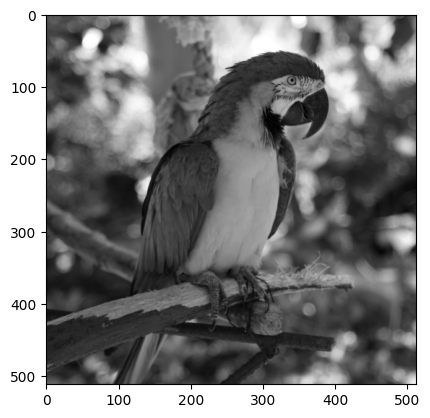

In [233]:
plt.imshow(X, cmap="gray")

89.340675


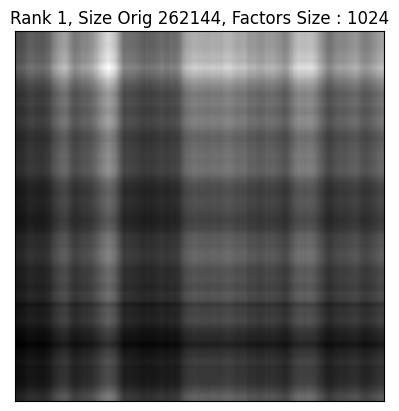

53.812386


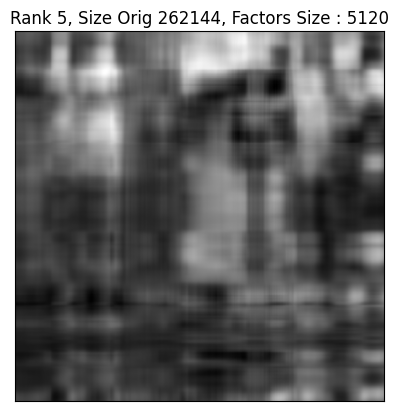

36.908966


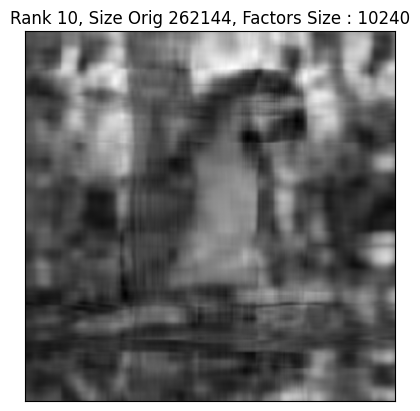

18.613243


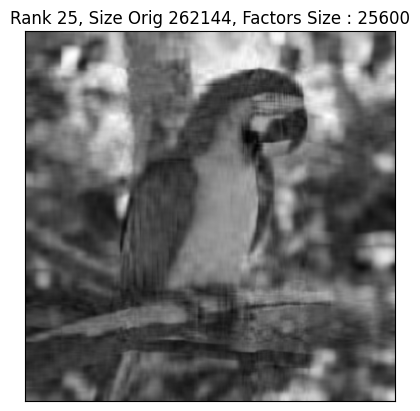

10.042118


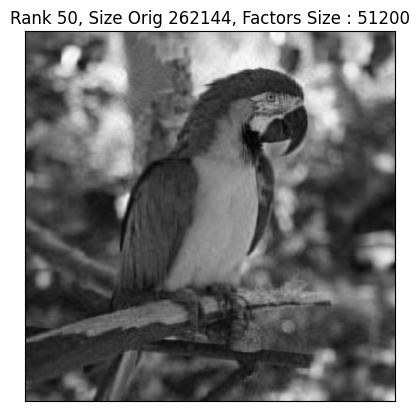

4.662434


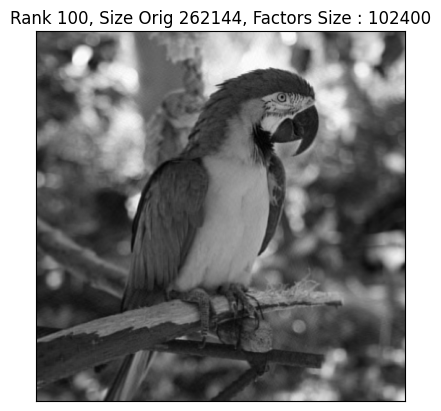

1.5414364


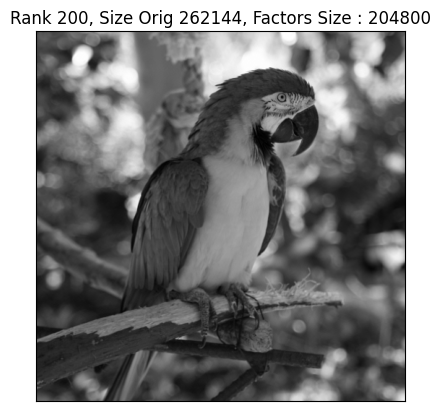

In [ ]:
from math import prod

for rank in [1, 5, 10, 25, 50, 100, 200]:
    factors = parafac(img, rank)
    X_rec = tensorly.cp_tensor.cp_to_tensor(factors)
    print(tensorly.norm(X - X_rec))
    plt.title(
        f"Rank {rank}, Size Orig {prod(X.shape)}, Factors Size : {sum(prod(f.shape) for f in factors.factors)}"
    )
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_rec, cmap="gray")
    plt.show()